In [29]:
import pandas as pd
import numpy as  np
from datetime import datetime

In [30]:
# loading the clean dataset

df_clean = pd.read_csv(r"C:\Users\User\Desktop\week 1&2\2_Netflix_Dataset_Cleaning_& _EDA\netflix_dataset_cleaned.csv")

In [31]:
# confirming if data types are correct

df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      8807 non-null   str  
 4   cast          8807 non-null   str  
 5   country       8807 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8800 non-null   str  
 9   duration      8807 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.8 MB


In [32]:
# fixing data type issue in date_added

df_clean["date_added"] = pd.to_datetime(df_clean["date_added"])

In [33]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   str           
 1   type          8807 non-null   str           
 2   title         8807 non-null   str           
 3   director      8807 non-null   str           
 4   cast          8807 non-null   str           
 5   country       8807 non-null   str           
 6   date_added    8797 non-null   datetime64[us]
 7   release_year  8807 non-null   int64         
 8   rating        8800 non-null   str           
 9   duration      8807 non-null   str           
 10  listed_in     8807 non-null   str           
 11  description   8807 non-null   str           
dtypes: datetime64[us](1), int64(1), str(10)
memory usage: 3.8 MB


In [35]:
# 1. movies vs tv show distribution

df_clean["type"].value_counts()

type
Movie      6131
Tv Show    2676
Name: count, dtype: int64

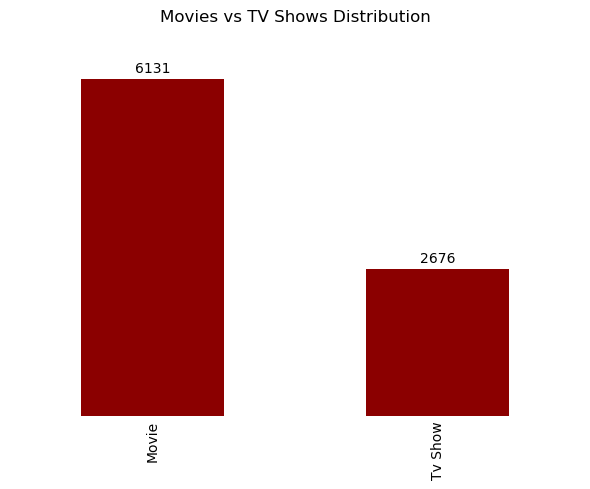

In [36]:
import matplotlib.pyplot as plt

movie_type_count = df_clean["type"].value_counts()

fig, ax = plt.subplots(figsize=(6, 5))

movie_type_count.plot(kind="bar", color="darkred", ax=ax)

# Show totals on top of bars
for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=3)

# Remove axis lines
for spine in ax.spines.values():
    spine.set_visible(False)

# Remove tick marks
ax.tick_params(length=0)

# Remove y-axis numbers
ax.set_yticklabels([])

# Remove axis titles
ax.set_xlabel("")
ax.set_ylabel("")

# Add space between title and chart
plt.title("Movies vs TV Shows Distribution", pad=30)

plt.tight_layout()
plt.show()

In [37]:
# 2. content added by year

# Extract year content was added
df_clean["year_added"] = df_clean["date_added"].dt.year

# Count titles added each year
content_by_year = df_clean["year_added"].value_counts().sort_index()

content_by_year.head()

year_added
2008.0     2
2009.0     2
2010.0     1
2011.0    13
2012.0     3
Name: count, dtype: int64

Text(0.5, 1.0, 'Content added by year')

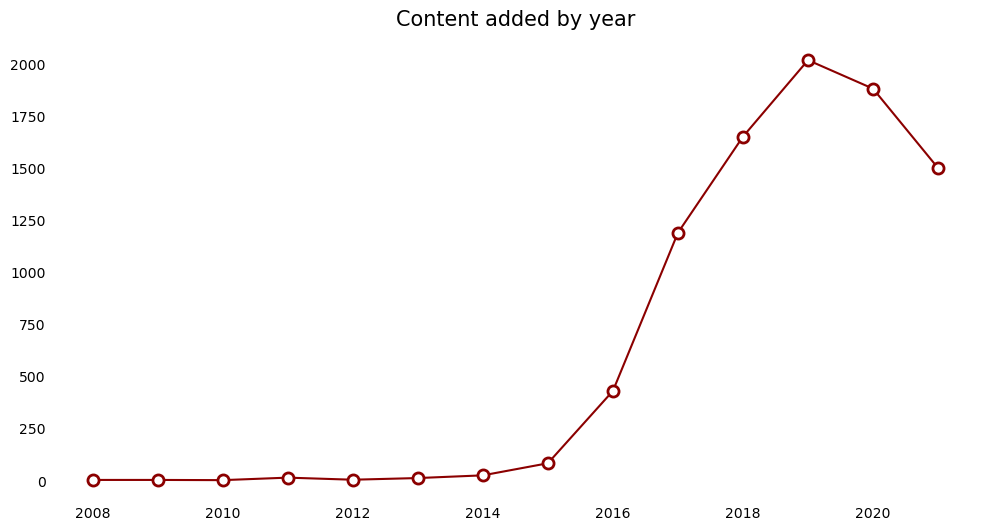

In [38]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
content_by_year.plot(kind = "line",  marker="o", markersize=8,
    markerfacecolor="white",
    markeredgewidth=2, color="darkred", ax=ax)

# removing the axis lines
for spine in ax.spines.values():
    spine.set_visible(False)
    
# removing tickmarks
ax.tick_params(length=0)

# removing axis labels
ax.set_xlabel("")
ax.set_ylabel("")

# adding title
plt.title("Content added by year", fontsize=15, pad= 10)



In [39]:
# 3. top content producing country

# Split multiple countries into separate rows
country_counts = (
    df_clean["country"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
)

print(country_counts.head(6))

country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Name: count, dtype: int64


Text(0.5, 1.0, 'Top Content Producing Countries')

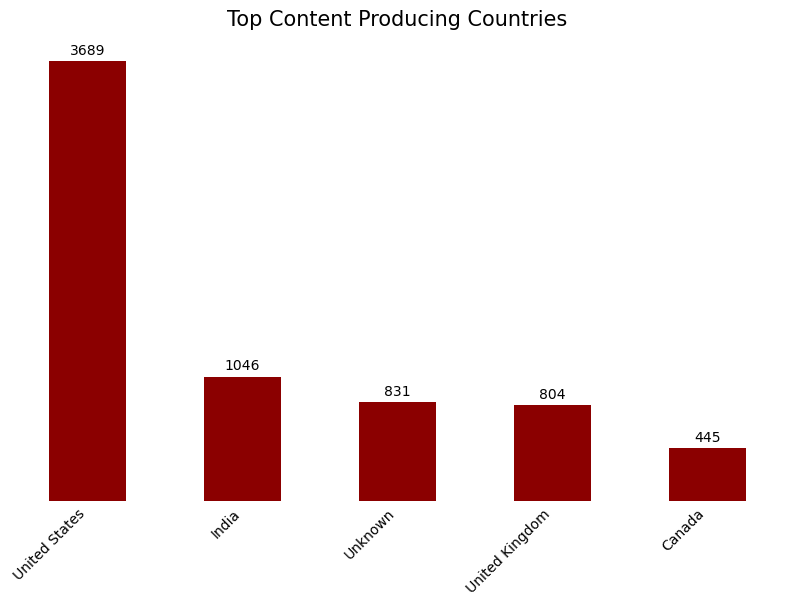

In [40]:
import matplotlib.pyplot as plt
top_countries = country_counts.head(5)

fig , ax = plt.subplots(figsize=(10,6))
top_countries.plot(kind="bar", color="darkred", ax=ax)

#remove the axis lines
for spine in ax.spines.values():
    spine.set_visible(False)
    
# remove axis tick marks
ax.tick_params(length =0)

#show total on top of bar 
for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding =3)

#removing y-lables
ax.set_yticklabels([])

# removing axis label
ax.set_ylabel("")
ax.set_xlabel("")

# Rotating the x-labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# adding title
plt.title("Top Content Producing Countries", fontsize=15, pad=10)


In [41]:
# Most common ratings

df_clean["rating"].value_counts().head(5)

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
Name: count, dtype: int64

Text(0.5, 1.0, 'Most Common Ratings')

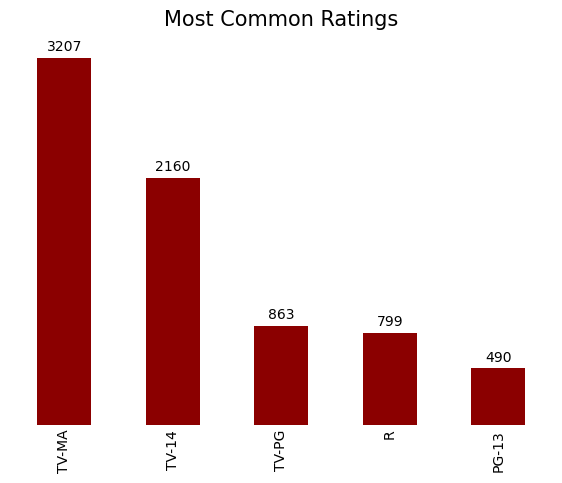

In [42]:
import matplotlib.pyplot as plt

common_rating = df_clean["rating"].value_counts().head(5)

fig, ax = plt.subplots(figsize=(7,5))

common_rating.plot(kind= "bar", color = "darkred", ax=ax )

# show total on top of bar
for container in ax.containers:
    ax.bar_label(container, fontsize =10, padding = 3)
    
# removing axis line
for spine in ax.spines.values():
    spine.set_visible(False)

# removing axis ticks
ax.tick_params(length=0)

# removing y-ticklabels
ax.set_yticklabels([])

# removing x-label
ax.set_xlabel("")

# adding title
plt.title("Most Common Ratings", fontsize = 15, pad = 10)


In [ ]:
# 4.Most common genre

df_clean["listed_in"].str.split(", ").explode().value_counts().head(6)

listed_in
International Movies      2752
Dramas                    2427
Comedies                  1674
International Tv Shows    1351
Documentaries              869
Action & Adventure         859
Name: count, dtype: int64

Text(0.5, 1.0, 'Most Common Genre')

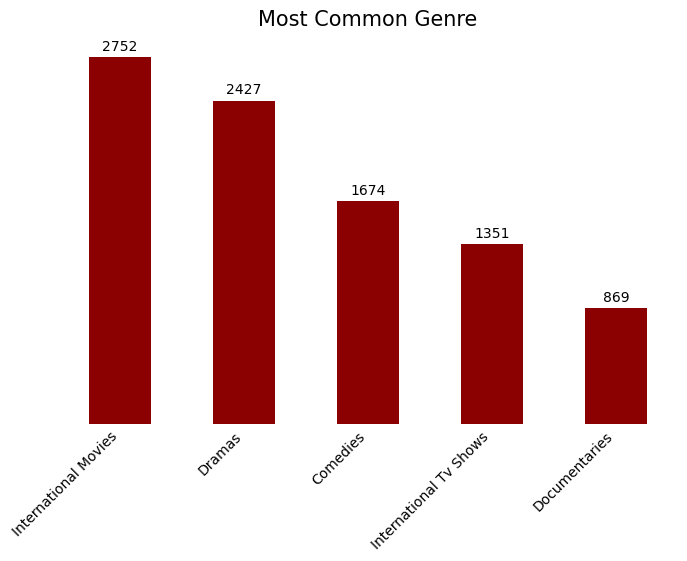

In [63]:
import matplotlib.pyplot as plt

top_genre = df_clean["listed_in"].str.split(", ").explode().value_counts().head(5)

fig, ax = plt.subplots(figsize= (8,5))

top_genre.plot(kind ="bar", color = "darkred", ax=ax)

# show total value on top of each bar
for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=3)
    
# remove axis line
for spine in ax.spines.values():
    spine.set_visible(False)
    
# remove axis tick
ax.tick_params(length=0)

# remove yticklabel
ax.set_yticklabels([])

# remove xlabel
ax.set_xlabel("")

# rotating xticklabel
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

#adding titles
plt.title("Most Common Genre", fontsize = 15, pad=10)




